In [1]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from torchvision import datasets, transforms
import torch.nn.functional as F
from training.models.losses import ArcFaceLoss
from training.models.arcface import MetricLearningModel
import seaborn as sns
import pandas as pd
from tqdm import tqdm
from evaluation.visualize import (
    plot_rejection_scores,
)
import gpytorch
from torch.utils.data import DataLoader
from utils_notebooks import predict_features, compute_distance_and_visualize
from botorch.models import SingleTaskGP
from botorch.models.transforms import Normalize, Standardize
from botorch.fit import fit_gpytorch_mll
from gpytorch.mlls import ExactMarginalLogLikelihood
from botorch.optim import optimize_acqf
from botorch.acquisition import LogExpectedImprovement

%load_ext autoreload
%autoreload 2

## 1. Train arcface on mnist

In [2]:
from toy_scf.models import (
    Backbone,
    train_arcface,
    compute_cosine_sim,
    predict_accuracy,
    load_arcface_model,
    load_scf_model,
    train_scf,
    compute_kappa,
)

transform = transforms.Compose(
    [transforms.ToTensor(), transforms.Normalize((0.1307,), (0.3081,))]
)
mnist_ds_train = datasets.MNIST(
    root="/app/datasets/mnist", train=True, download=True, transform=transform
)
mnist_ds_test = datasets.MNIST(
    root="/app/datasets/mnist", train=False, download=True, transform=transform
)

### 1.1 Train Arcface on full ds

In [3]:
NUM_FEATURES = 2

backbone_model = Backbone(num_features=NUM_FEATURES)
arcface_loss = ArcFaceLoss()
scheduler_params = {
    "scheduler": "OneCycleLR",
    "params": {
        "max_lr": 3e-2,
        "steps_per_epoch": len(mnist_ds_train) // 400,
        "epochs": 100,
        "div_factor": 1e2,
        "final_div_factor": 1e2,
    },
    "interval": "step",
    "frequency": 1,
}
arcface_model = MetricLearningModel(
    backbone_model,
    arcface_loss,
    num_labels=10,
    train_set=mnist_ds_train,
    val_set=mnist_ds_test,
    batch_size=400,
    num_workers=4,
    num_features=NUM_FEATURES,
    scheduler_params=scheduler_params,
)
exp_name = "ArcfaceMnist"
# train_arcface(arcface_model, f"/app/outputs/{exp_name}", exp_name, run_name='full_mnist', max_epoch=100)

/home/l.erlygin/miniconda/lib/python3.9/site-packages/pytorch_lightning/utilities/parsing.py:197: UserWarning: Attribute 'backbone' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['backbone'])`.
  rank_zero_warn(
/home/l.erlygin/miniconda/lib/python3.9/site-packages/pytorch_lightning/utilities/parsing.py:197: UserWarning: Attribute 'loss' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['loss'])`.
  rank_zero_warn(


100%|██████████| 25/25 [00:00<00:00, 44.13it/s]


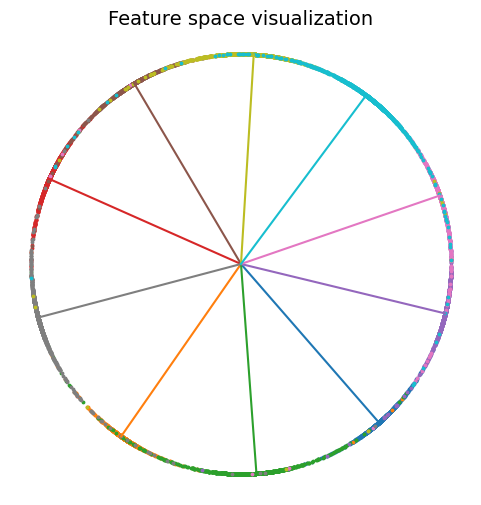

Test accuracy: 0.9304


100%|██████████| 79/79 [00:01<00:00, 66.57it/s]
/tmp/ipykernel_60660/737773848.py:26: RuntimeWarning: invalid value encountered in arccos
  "test": (np.arccos(cosine_sim_test) / (2 * np.pi)) * 360,
/tmp/ipykernel_60660/737773848.py:27: RuntimeWarning: invalid value encountered in arccos
  "train": (np.arccos(cosine_sim_train) / (2 * np.pi)) * 360,


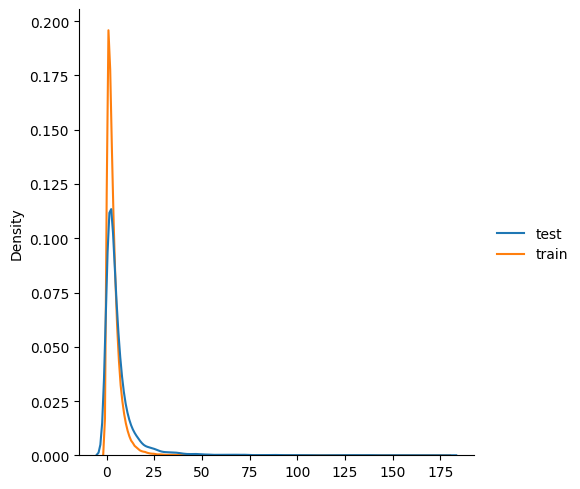

In [4]:
train_dl = DataLoader(
    mnist_ds_train,
    batch_size=128,
    shuffle=False,
    drop_last=False,
    num_workers=32,
)
test_dl = DataLoader(
    mnist_ds_test,
    batch_size=128,
    shuffle=False,
    drop_last=False,
    num_workers=32,
)
arcface_model = load_arcface_model(
    mnist_ds_train,
    mnist_ds_test,
    "/app/outputs/ArcfaceMnist/ckpt/epoch=79-val_loss=1.06.ckpt",
    visualize=True,
)
file_name = "full_mnist"
compute_cosine_sim(arcface_model, train_dl, test_dl, file_name)
cosine_sim_train = np.load(f"outputs/train_{file_name}_cosine_sim.npy")
cosine_sim_test = np.load(f"outputs/test_{file_name}_cosine_sim.npy")
data = {
    "test": (np.arccos(cosine_sim_test) / (2 * np.pi)) * 360,
    "train": (np.arccos(cosine_sim_train) / (2 * np.pi)) * 360,
}
sns.displot(
    data,
    kind="kde",
    log_scale=False,
    common_norm=False,
)

In [5]:
np.sum((np.arccos(cosine_sim_train) / (2 * np.pi)) * 360 > 18), len(cosine_sim_train)

/tmp/ipykernel_60660/2342528981.py:1: RuntimeWarning: invalid value encountered in arccos
  np.sum((np.arccos(cosine_sim_train) / (2 * np.pi)) * 360 > 18), len(cosine_sim_train)


(859, 60000)

In [6]:
EPS = 1e-6
angle = 18
angles = (np.arccos(np.clip(cosine_sim_train, -1.0 + EPS, 1.0 - EPS)) / (np.pi)) * 180
mnist_ds_train_filtered = torch.utils.data.Subset(
    mnist_ds_train,
    np.where(angles < angle)[0],
)
len(mnist_ds_train_filtered)

59141

In [8]:
NUM_FEATURES = 2

backbone_model = Backbone(num_features=NUM_FEATURES)
arcface_loss = ArcFaceLoss()

scheduler_params = {
    "scheduler": "OneCycleLR",
    "params": {
        "max_lr": 3e-2,
        "steps_per_epoch": len(mnist_ds_train) // 400,
        "epochs": 100,
        "div_factor": 1e2,
        "final_div_factor": 1e2,
    },
    "interval": "step",
    "frequency": 1,
}

arcface_model = MetricLearningModel(
    backbone_model,
    arcface_loss,
    num_labels=10,
    train_set=mnist_ds_train_filtered,
    val_set=mnist_ds_test,
    batch_size=400,
    num_workers=4,
    num_features=NUM_FEATURES,
    scheduler_params=scheduler_params,
)
run_name = f"arcface_angle_{angle}_filtered_mnist"
train_arcface(
    arcface_model, f"/app/outputs/{exp_name}", exp_name, run_name, max_epoch=100
)

/home/l.erlygin/miniconda/lib/python3.9/site-packages/pytorch_lightning/utilities/parsing.py:197: UserWarning: Attribute 'backbone' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['backbone'])`.
  rank_zero_warn(
/home/l.erlygin/miniconda/lib/python3.9/site-packages/pytorch_lightning/utilities/parsing.py:197: UserWarning: Attribute 'loss' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['loss'])`.
  rank_zero_warn(
wandb: Currently logged in as: aspek to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
You are using a CUDA device ('NVIDIA L40S') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name     | Type        | Params
-----------------------------------------
0 | backbone | Backbone    | 37.4 K
1 | loss     | ArcFaceLoss | 0     
-----------------------------------------
37.5 K    Trainable params
0         Non-trainable params
37.5 K    Total params
0.150     Total estimated model params size (MB)


Sanity Checking: 0it [00:00, ?it/s]

Training: 0it [00:00, ?it/s]

Validation: 0it [00:00, ?it/s]

...

Validation: 0it [00:00, ?it/s]

Validation: 0it [00:00, ?it/s]

Validation: 0it [00:00, ?it/s]

Validation: 0it [00:00, ?it/s]

`Trainer.fit` stopped: `max_epochs=100` reached.


/home/l.erlygin/miniconda/lib/python3.9/site-packages/pytorch_lightning/utilities/parsing.py:197: UserWarning: Attribute 'backbone' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['backbone'])`.
  rank_zero_warn(
/home/l.erlygin/miniconda/lib/python3.9/site-packages/pytorch_lightning/utilities/parsing.py:197: UserWarning: Attribute 'loss' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['loss'])`.
  rank_zero_warn(
100%|██████████| 25/25 [00:00<00:00, 43.47it/s]


Test accuracy: 0.9322


100%|██████████| 79/79 [00:01<00:00, 60.07it/s]
/tmp/ipykernel_60660/2060595631.py:25: RuntimeWarning: invalid value encountered in arccos
  "test": (np.arccos(cosine_sim_test) / (2 * np.pi)) * 360,
/tmp/ipykernel_60660/2060595631.py:26: RuntimeWarning: invalid value encountered in arccos
  "train": (np.arccos(cosine_sim_train) / (2 * np.pi)) * 360,


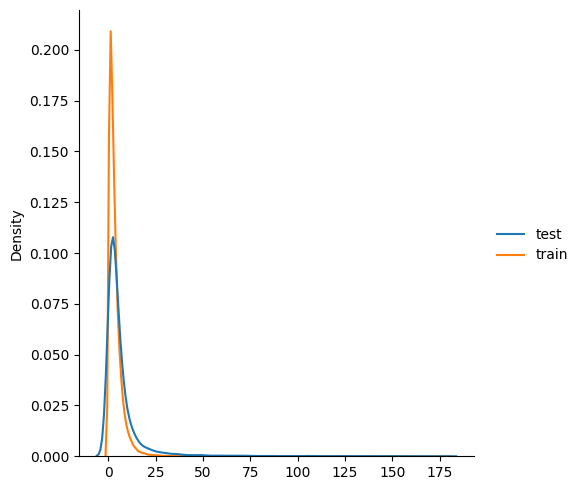

In [9]:
train_dl = DataLoader(
    mnist_ds_train_filtered,
    batch_size=128,
    shuffle=False,
    drop_last=False,
    num_workers=32,
)
test_dl = DataLoader(
    mnist_ds_test,
    batch_size=128,
    shuffle=False,
    drop_last=False,
    num_workers=32,
)
arcface_model = load_arcface_model(
    mnist_ds_train_filtered,
    mnist_ds_test,
    "/app/outputs/ArcfaceMnist/arcface_angle_18_filtered_mnist/ckpt/epoch=89-val_loss=1.08.ckpt",
)
file_name = f"angle_{angle}_filtered_mnist"
compute_cosine_sim(arcface_model, train_dl, test_dl, file_name)
cosine_sim_train = np.load(f"outputs/train_{file_name}_cosine_sim.npy")
cosine_sim_test = np.load(f"outputs/test_{file_name}_cosine_sim.npy")
data = {
    "test": (np.arccos(cosine_sim_test) / (2 * np.pi)) * 360,
    "train": (np.arccos(cosine_sim_train) / (2 * np.pi)) * 360,
}
sns.displot(
    data,
    kind="kde",
    log_scale=False,
    common_norm=False,
)